# 第23课 · 闭着眼也能找到最陡的上坡——梯度（gradient）与偏导（∂f/∂x）拼成的方向向量

**学习目标**：多变量函数对每个变量求偏导，拼成梯度 $\nabla f$——指向上升最快的方向。

> **标题「上坡」vs 训练「下山」**：同一支箭头，上坡 $+\nabla f$，下山 $-\nabla f$。本课先会读；L25 再沿负方向走。

**为什么对 Aurora 重要**：`backward` 算出损失对每个权重的偏导，拼成梯度；优化器拿它更新参数。


← **上一课**　[L22 · 导数](L22_derivatives.ipynb)

> 上节课学习了 **导数**：切线斜率、极限定义、数值微分 vs 解析微分。  
> 本课将探讨 **梯度**。

## 本课剧情：损失函数的最陡下坡在哪里？

想象你站在一座山上，闭着眼睛想找最快下山的路。  
你的脚能感受到"每个方向的坡度"——梯度（gradient）就是把这些坡度打包成一个向量。

对于多元函数（multivariate function） f(x₁, x₂, ..., xₙ)，梯度是：

$$\nabla f = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)$$

每个分量 ∂f/∂xᵢ 告诉你：**固定其他所有变量，只沿 xᵢ 方向移动一点，函数值怎么变？**

梯度向量指向**函数值增加最快**的方向（最陡上坡）。  
要让损失函数下降，就沿梯度的**反方向**走——这就是梯度下降（L25）的全部逻辑。

本课用中心差分（central difference）对每个分量数值化：

```python
∇f[i] ≈ (f(point + hᵢ) - f(point - hᵢ)) / (2h)
```

实现 `gradient(f, point, h=1e-5)`，对 Aurora 的任意损失函数都能用。

### 先认识两个新符号：∂ 和 ∇

上面的公式里冒出两个 L22 没见过的符号，看着有点陌生，先把它们的"名字"和"读法"讲清楚——数学符号本身不难，难的是没人告诉你它叫什么。

**∂ ——读作"偏导符号"（partial d）**

L22 里，一元函数的导数写成 `f'(x)` 或 `df/dx`，用的是普通的字母 `d`。这里换成了 `∂`（形状像 d，但是个独立的符号，键盘上打不出来，数学家称它为 "partial"）。为什么要换一个符号，而不是继续用 `d`？

因为 `d` 暗含一个假设："只有一个变量在动"。但 `f(x, y)` 这种多元函数里，`x` 和 `y` 可以同时变化，"函数值怎么变"要看两者如何联动——那是"全导数"（total derivative）的范畴，这门课不展开。`∂f/∂x` 换用 `∂` 就是在提醒你：**这里只放行 x 一个变量动，y 被临时焊死不动**——一种"部分"（partial）的求导，所以叫偏导数。看到 `∂` 就知道：背后还有被按住不动的变量。

**∇ ——读作"nabla"（纳布拉）或"del"**

`∇f` 这个倒三角符号叫 "nabla"（音似"纳布拉"），因为它的形状像古代一种叫 nabla 的竖琴。你不需要记住这个历史八卦，只需要知道：**`∇` 不是一种新的运算，只是"把所有偏导数按顺序拼成一个向量"这个动作的简写**。

$$\nabla f = \left(\frac{\partial f}{\partial x_1}, \ldots, \frac{\partial f}{\partial x_n}\right)$$

读作"nabla f"或直接读"梯度 f"。看到 `∇f`，脑子里翻译成："对每个变量分别求偏导，然后把结果按顺序排成一个向量。"仅此而已。

## 1. 偏导数：一次只问一个方向

**类比**：你是一个盲人厨师，想知道"汤的味道随盐量变化有多快"。  
你固定其他所有配料（水量、温度、火候），只改变盐量——这就是偏导数：

$$\frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h, y) - f(x-h, y)}{2h}$$

**手算例子**：f(x, y) = x² + y²

- ∂f/∂x：把 y 视为常数，对 x 求导 → ∂f/∂x = 2x
- ∂f/∂y：把 x 视为常数，对 y 求导 → ∂f/∂y = 2y

在点 (3, 4) 处：∇f(3,4) = [2×3, 2×4] = [6, 8]

**梯度的方向是什么？**  
梯度向量（gradient vector） [6, 8] 垂直于等高线（contour line）f(x,y)=25 在 (3,4) 处的切线，指向函数值增大最快的方向。

> 实现 `gradient(f, point)` 时：对每个分量 i，构造 ±h 的微扰向量，做中心差分。

### 把 y 焊死再求导——这样做真的合法吗？

上面一步写得很快："把 y 视为常数，对 x 求导 → ∂f/∂x = 2x"，但为什么"锁住一个变量"就能直接套用 L22 学过的一元求导法则？这不是偷懒，是有严格理由的。

**类比**：把 f(x, y) 想象成一张地形图，`x` 是经度，`y` 是纬度，`f` 是海拔。现在你站在纬度 `y=4` 这条线上，问："只沿经度方向走，海拔怎么变？"——这等于把整张地图"切"出纬度恒为 4 的那一条剖面线，剖面线上海拔只随经度 `x` 变化，变成了一条实实在在的**一元函数曲线**。

**形式化地写一遍**：固定 `y = y₀`，定义一个新的一元函数

$$g(x) = f(x, y_0)$$

`g` 就是"把 y 焊死在 y₀"之后剩下的那条剖面曲线，它只有一个自变量 `x`——跟 L22 里的 `f(x)=x²` 没有任何本质区别。按 L22 的定义直接对 `g` 求导：

$$g'(x_0) = \lim_{h \to 0} \frac{g(x_0+h) - g(x_0)}{h} = \lim_{h \to 0} \frac{f(x_0+h, y_0) - f(x_0, y_0)}{h}$$

而这个极限，正是偏导数 `∂f/∂x` 在 `(x₀, y₀)` 处的**定义**。也就是说：

$$\frac{\partial f}{\partial x}(x_0, y_0) = g'(x_0)$$

**偏导数根本不是什么新概念——它就是"先把其他变量焊死，坍缩成一元函数，再用 L22 的普通求导法则"这一步操作的名字。** 这就是为什么"把 y 当常数"是合法的：焊死之后，`y` 已经不再是变量了，剩下的确确实实是一个只带 `x` 的普通函数。

### 手把手推导一遍：∂f/∂x = 2x 到底怎么来的

结论不能只靠"代公式"记住，下面把 `f(x,y)=x²+y²` 的 `∂f/∂x` 用本课给出的中心差分定义完整推一遍——每一步都写出来，没有跳步。

第一步，把定义抄下来，`y` 焊死不动：

$$\frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h, y) - f(x-h, y)}{2h}$$

第二步，把 `f(x,y)=x²+y²` 代进去，分别展开分子的两项：

$$f(x+h, y) = (x+h)^2 + y^2 = x^2 + 2xh + h^2 + y^2$$
$$f(x-h, y) = (x-h)^2 + y^2 = x^2 - 2xh + h^2 + y^2$$

第三步，两式相减——注意 `x²`、`h²`、`y²` 这些不带符号变化的项会直接抵消，只留下带 `h` 一次方、符号相反的那一项：

$$f(x+h,y) - f(x-h,y) = (2xh) - (-2xh) = 4xh$$

第四步，除以 `2h`：

$$\frac{4xh}{2h} = 2x$$

这里 `h` 完全约掉了，跟 L22 的 `f(x)=x²` 例子一样——`h→0` 的极限甚至不需要真的取，因为结果本来就和 `h` 无关，直接等于 `2x`。这就是 `∂f/∂x=2x` 的完整来源：不是"看出来的规律"，而是把定义式老老实实展开、相减、约分算出来的。`∂f/∂y=2y` 用完全相同的步骤（这次焊死 `x`，对 `y` 展开）可以推出，作为练习自己动手算一遍会比看别人算更有感觉。

### 复习一下：为什么偏导数也用"除以 2h"的中心差分？

本课的公式直接搬来了 `(f(x+h)-f(x-h))/(2h)`，如果你已经忘了这是什么、为什么要除以 `2h`，说明是时候回 [L22 · 导数](L22_derivatives.ipynb) 翻一翻——那一课用泰勒展开完整推过这件事，这里只做一个"贴着本课场景"的快速复习，不重复推导。

**三种差分，回忆一下定义**：

| 名字 | 公式 | 误差阶 |
|---|---|---|
| 前向差分 | `(f(x+h)-f(x))/h` | O(h) |
| 后向差分 | `(f(x)-f(x-h))/h` | O(h) |
| 中心差分 | `(f(x+h)-f(x-h))/(2h)` | O(h²) |

`2h` 里的 `2`，来自"从 `x-h` 走到 `x+h`，水平距离是 `2h`"——分子是两点间的"高度差"，分母是两点间的"水平距离"，斜率 = 高度差 / 水平距离，跟"两点确定一条割线"的最朴素想法完全一致。而中心差分之所以比前向/后向精度更高（误差从 O(h) 降到 O(h²)），根本原因是它左右对称——泰勒展开时，`x+h` 和 `x-h` 两侧展开式相减，会把误差最大的那一项（带 `f''(x)h²` 的项）互相抵消掉，只剩下更小的 `f'''(x)h³` 量级误差。L22 用具体数字验证过：`h=1e-5` 时前向差分误差约 `1e-5`，中心差分误差约 `1e-10`——差了 5 个数量级。

**放到偏导数这里**，逻辑完全一样：`∂f/∂x` 本质上就是"把 y 焊死之后的一元函数 g(x) 的导数"（上面刚推过），所以 g 用中心差分求导的所有性质原封不动地继承过来——包括"h≈1e-5 附近误差最小"这个经验结论。下面用代码复现一下：在 `(3,4)` 处，对比"前向差分"和"中心差分"算出的 `∂f/∂x`，看看谁更接近解析值 `2x=6`。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

f = lambda p: p[0]**2 + p[1]**2
p = np.array([3.0, 4.0])
true_dfdx = 2 * p[0]  # 解析值 = 6

print(f"{'h':>10} {'前向差分误差':>16} {'中心差分误差':>16}")
h = 1e-1
for _ in range(6):
    forward = (f(p + [h, 0]) - f(p)) / h
    central = (f(p + [h, 0]) - f(p - [h, 0])) / (2 * h)
    print(f"{h:10.0e} {abs(forward - true_dfdx):16.3e} {abs(central - true_dfdx):16.3e}")
    h /= 10

print("\n跟 L22 的结论一致：中心差分的误差随 h 缩小得比前向差分快得多——")
print("这就是本课偏导数公式选中心差分、除以 2h 的原因。")

         h           前向差分误差           中心差分误差
     1e-01        1.000e-01        3.553e-15
     1e-02        1.000e-02        1.279e-13
     1e-03        1.000e-03        1.549e-12
     1e-04        1.000e-04        3.780e-12
     1e-05        1.000e-05        1.281e-10
     1e-06        1.001e-06        8.387e-10

跟 L22 的结论一致：中心差分的误差随 h 缩小得比前向差分快得多——
这就是本课偏导数公式选中心差分、除以 2h 的原因。


### 等高线到底是什么？

课文说梯度"垂直于等高线"，但如果你从没见过这个词，这句话是空的。先从最直观的地方说起——**等高线**这个词本来就来自地图：爬山时地图上那些一圈一圈的曲线，每一条线上所有的点海拔都相同，线越密的地方坡越陡。把这个概念搬到数学里：

对一个二元函数 `f(x,y)`，取一个常数 `c`，所有满足

$$f(x,y) = c$$

的点 `(x,y)` 连起来，就是一条"等高线"（也叫等值线）——线上每一点，函数值都是同一个 `c`，"高度"处处相等，这也是"等高"这个名字的来源。

**为什么 `f(x,y)=x²+y²` 的等高线是同心圆？** 这不是背出来的，是代数上直接看出来的：设 `f(x,y)=c`，即 `x²+y²=c`。而 `√(x²+y²)` 正是点 `(x,y)` 到原点的距离——所以 `x²+y²=c` 等价于"到原点的距离恒等于 `√c`"，这正是**圆**的定义（到定点距离相等的点的集合）。`c` 取不同的值，就得到半径不同、但同心（都以原点为圆心）的一圈圈圆——这就是"同心圆"的由来。

下面画出来看一眼，比文字描述直观得多：

红色箭头（梯度）垂直于蓝色等高线圆；绿色箭头（切线）沿着圆走，f 值不变。


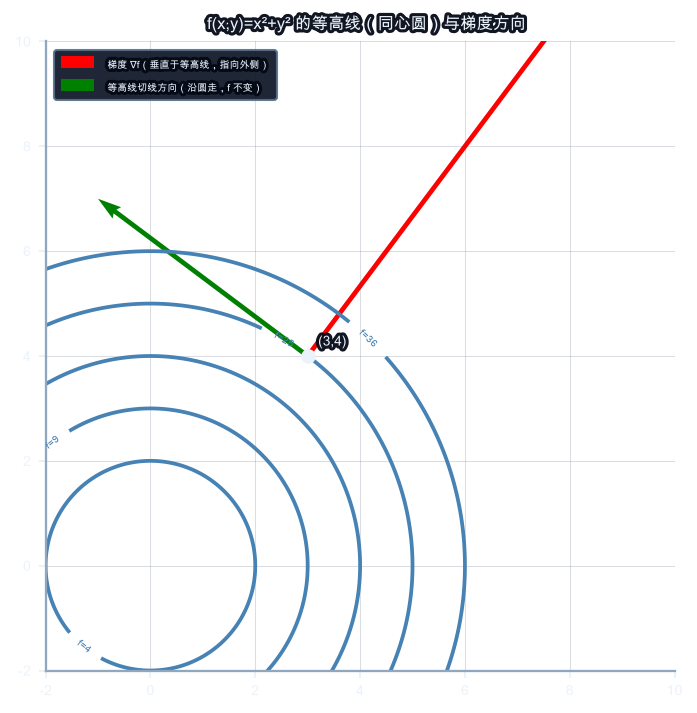

In [3]:
import numpy as np
import matplotlib.pyplot as plt

xg = np.linspace(-6, 6, 300)
yg = np.linspace(-6, 6, 300)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg**2 + Yg**2  # f(x,y) = x^2 + y^2

point = np.array([3.0, 4.0])
grad_here = np.array([2 * point[0], 2 * point[1]])          # 解析梯度 [6, 8]
tangent_here = np.array([-point[1], point[0]])               # 等高线切线方向 (-4, 3)

fig, ax = plt.subplots(figsize=(5, 5))
contours = ax.contour(Xg, Yg, Zg, levels=[4, 9, 16, 25, 36], colors="steelblue")
ax.clabel(contours, inline=True, fontsize=8, fmt="f=%d")

ax.quiver(*point, *grad_here, color="red", angles="xy", scale_units="xy", scale=1,
          label="梯度 ∇f（垂直于等高线，指向外侧）")
ax.quiver(*point, *tangent_here, color="green", angles="xy", scale_units="xy", scale=1,
          label="等高线切线方向（沿圆走，f 不变）")
ax.scatter(*point, color=plt.rcParams["text.color"], zorder=5)
ax.annotate("(3,4)", point + [0.2, 0.2])

ax.set_xlim(-2, 10); ax.set_ylim(-2, 10)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("f(x,y)=x²+y² 的等高线（同心圆）与梯度方向")
plt.tight_layout(); plt.show()

print("红色箭头（梯度）垂直于蓝色等高线圆；绿色箭头（切线）沿着圆走，f 值不变。")

### 切线方向 (-4,3) 是怎么算出来的？——旋转 90° 的小技巧

图里绿色的切线方向是 `(-4, 3)`，看起来像是凭空冒出来的数字，其实背后是一个非常通用、不需要死记的小技巧：**把一个二维向量旋转 90°，只需要"交换两个分量，再给其中一个添负号"**。

具体来说，任何向量 `(a, b)` 旋转 90° 后得到 `(-b, a)`（逆时针）。验证一下这确实是垂直的——用点积检验："垂直"的数学定义就是点积为零：

$$(a, b) \cdot (-b, a) = a\times(-b) + b \times a = -ab + ab = 0$$

注意这个等式对**任意** `a, b` 都成立——`-ab+ab` 永远抵消为零，跟 `a, b` 具体是多少无关。这是一个纯代数恒等式，不是巧合，也不需要针对每个点重新推导。

回到等高线：在点 `(3,4)`，梯度是 `(6,8)`（正比于 `(3,4)` 本身，因为 `∇f=(2x,2y)=2(x,y)`）。圆上一点的切线，几何上就是垂直于"圆心到这一点"的半径方向——而半径方向正好和梯度方向平行（都是 `(x,y)` 的方向）。所以切线方向 = 半径方向旋转 90° = `(3,4)` 旋转90° = `(-4,3)`。同样地，点 `(1,2)` 处，半径方向是 `(1,2)`，切线方向就是 `(-2,1)`——用的是同一个"交换分量、添负号"的旋转技巧，不是死记硬背的数字，任何点都能现算。

**这也解释了 `cell-l23-0217` 代码里那句注释**："`tangent=[-g[1],g[0]]` 的点积恒为 `-ab+ba=0`（代数恒等式，与实现无关，不能检验正确性）"——因为不管 `gradient()` 函数算得对不对，`(a,b)` 和 `(-b,a)` 点积恒为零，这个检验永远会通过，测不出 bug。所以notebook 代码改用"梯度方向应与位置向量方向一致（径向朝外）"来做真正的正确性检验，而不是"梯度⊥切线"这条重言式。

### 为什么"垂直于等高线"就意味着"最陡"？

这是这一课最容易含糊过去、但也最值得讲透的一点。三位同学都问到了同一个疑惑：沿等高线走，函数值当然不变（废话）；但为什么"垂直"方向恰好是**所有**方向里变化最快的那一个，而不只是"随便一个会变化的方向"？

**关键工具：方向导数（directional derivative）**。它回答的问题是——"从某一点出发，沿任意指定方向 `u`（长度为 1 的单位向量）走一点点，函数值变化有多快？" 结论（这门课先给出结论，证明留到更进阶的课程）是：

$$D_u f = \nabla f \cdot u = \|\nabla f\| \, \|u\| \cos\theta = \|\nabla f\| \cos\theta$$

其中 `θ` 是梯度向量 `∇f` 与你选择的方向 `u` 之间的夹角（`‖u‖=1` 所以省略）。这个式子的含义：**沿方向 `u` 的变化率，等于梯度的长度乘以一个"对齐程度"因子 `cosθ`**——`u` 和梯度越对齐（`θ` 越小），变化率越大。

把这个式子当函数看，自变量是 `θ`：`cosθ` 什么时候最大？`θ=0`，也就是 `u` 和梯度方向**完全一致**的时候，`cosθ=1`，取得最大值 `‖∇f‖`——这就是"梯度方向 = 最陡上坡方向"的真正来源，不是直觉猜测，是把方向导数看成 `θ` 的函数求最大值。

再看 `θ=90°`（即 `u` 垂直于梯度）：`cosθ=0`，方向导数 `D_u f = 0`——**沿这个方向走，函数值瞬时变化率为零**。而"函数值不变"正是等高线的定义！所以：**垂直于梯度的方向，函数值变化率为零，也就是沿着等高线走；反过来，等高线的切线方向必然垂直于梯度**——这两句话说的是同一件事，只是站在不同角度看。梯度方向被"挤"到了唯一剩下的、变化率最大的方向上，因为它是"离开等高线最快"的方向——这也是为什么图里红色箭头（梯度）看起来是从圆"往外冲"，而不是贴着圆走。

### 顺便认识一个名字：什么是"法向量"？

前面一直在说"梯度垂直于等高线的切线"，这句话其实有个更短的说法——数学上，**在曲线（或曲面）上某一点，垂直于该点切线方向的向量，就叫这条曲线在这一点的"法向量"（normal vector）**。"法"在这里是"垂直、正交"的意思（类似"垂直"叫"法线"），不是什么新的计算，只是给"垂直方向"这件事起的一个名字。

拿圆举例最直观：圆上任意一点，切线是"贴着圆走"的方向，而法向量就是"垂直于切线"的方向——也就是**沿半径**的方向（要么从圆心指向这一点，要么反过来）。画一个圆随手一看就能确认这一点：圆心到圆上一点的连线（半径），天然垂直于这一点的切线，这是圆的几何定义直接决定的。

所以三句话说的是同一件事，只是换了角度描述：**梯度方向 = 函数值上升最快的方向 = 等高线在该点的法向量**。对 `f(x,y)=x²+y²` 这种以原点为圆心的同心圆，法向量正好就是径向（半径方向）——这也是为什么前面算梯度 `(6,8)` 时，发现它正好和位置向量 `(3,4)` 同向（成比例）：因为对这个特定的圆形等高线来说，"法向量"和"径向"本来就是一回事。

## 实验入口：用数值变化观察函数

观察 `dfdx` 和 `dfdy` 在点 `(3, 4)` 处的值，确认中心差分结果与解析公式 `∂f/∂x = 2x = 6`、`∂f/∂y = 2y = 8` 的误差在 1e-9 以内。


In [4]:
import numpy as np
f = lambda p: p[0]**2 + p[1]**2     # f(x,y) = x^2 + y^2
h = 1e-5
p = np.array([3.0, 4.0])
dfdx = (f(p+[h,0]) - f(p-[h,0]))/(2*h)
dfdy = (f(p+[0,h]) - f(p-[0,h]))/(2*h)
print('∂f/∂x ≈', round(dfdx,3), '(真值2x=6)  ∂f/∂y ≈', round(dfdy,3), '(真值2y=8)')

∂f/∂x ≈ 6.0 (真值2x=6)  ∂f/∂y ≈ 8.0 (真值2y=8)


## 动手观察：变化率不是一句口号

对一元函数 `f(x) = x²` 在五个点上分别用中心差分估计斜率，打印结果与解析值 `f'(x) = 2x` 对比，直观感受 h=1e-3 时的数值精度。


In [5]:
import numpy as np

def f(x):
    return x**2

xs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
h = 1e-3
slopes = (f(xs + h) - f(xs - h)) / (2 * h)

print('x =', xs)
print('f(x) =', f(xs))
print('近似斜率 =', np.round(slopes, 3))
print('理论斜率 2x =', 2 * xs)


x = [-2. -1.  0.  1.  2.]
f(x) = [4. 1. 0. 1. 4.]
近似斜率 = [-4. -2.  0.  2.  4.]
理论斜率 2x = [-4. -2.  0.  2.  4.]


## 代码实验：遍历不同位置，看斜率如何变化

遍历 `x ∈ [-3, 3]` 的七个点，打印每处的函数值与数值斜率，确认斜率始终接近解析导数 `f'(x) = 2x + 2`。


In [6]:
import numpy as np

def f(x):
    return x**2 + 2*x

h = 1e-4
for x in np.linspace(-3, 3, 7):
    slope = (f(x + h) - f(x - h)) / (2*h)
    print(f'x={x:5.2f} | f(x)={f(x):6.2f} | slope≈{slope:6.2f}')


x=-3.00 | f(x)=  3.00 | slope≈ -4.00
x=-2.00 | f(x)=  0.00 | slope≈ -2.00
x=-1.00 | f(x)= -1.00 | slope≈  0.00
x= 0.00 | f(x)=  0.00 | slope≈  2.00
x= 1.00 | f(x)=  3.00 | slope≈  4.00
x= 2.00 | f(x)=  8.00 | slope≈  6.00
x= 3.00 | f(x)= 15.00 | slope≈  8.00


## 2. ✏️ 实现 `gradient(f, point, h=1e-5)`

对每个分量做一次中心差分，返回梯度向量。

**推理路线**：
1. 初始化 `grad = np.zeros_like(point)`，确保输出 shape 与输入相同
2. 对每个维度 i，构造单位扰动向量 `e`：`e = np.zeros_like(point); e[i] = 1.0`，其余分量为 0
3. 计算 `(f(point + e*h) - f(point - e*h)) / (2 * h)`，存入 `grad[i]`（两种写法等价，本课统一用单位向量乘 h 的形式，与下方变量表一致）
4. 关键点：每次只扰动第 i 维，其余维度不变——这正是偏导数"固定其他变量"的操作

**参考输入输出**：f(x, y) = x² + y², point = [3, 4] → ∂f/∂x = 2×3 = 6, ∂f/∂y = 2×4 = 8 → 梯度 = [6, 8]

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `gradient` 前明确三件事：
- 输入：`f`（可调用函数）、`point`（n 维 numpy 数组）、`h`（步长，默认 1e-5）
- 关键步骤：对每个维度 i 构造单位扰动向量 `e`，计算 `(f(p + e*h) - f(p - e*h)) / (2h)`
- 返回：长度为 n 的 numpy 数组，第 i 个元素是 ∂f/∂xᵢ 在 `point` 处的值


### "单位扰动向量" `e` 到底是什么，为什么不嫌麻烦地构造它？

推理路线第 2 步写了一句容易被跳过的话：`e = np.zeros_like(point); e[i] = 1.0`。这里出现了两个容易卡住的地方：这个 `e` 为什么叫"单位向量"，以及为什么不直接手写 `[0,...,h,...,0]` 这样的列表。

**"单位向量"这个名字从哪来？** 回忆一下 3D 空间里最基础的三个方向——沿 x 轴、y 轴、z 轴分别是：

```
e_x = (1, 0, 0)      # 只在第 0 维是 1，长度=1
e_y = (0, 1, 0)      # 只在第 1 维是 1，长度=1
e_z = (0, 0, 1)      # 只在第 2 维是 1，长度=1
```

这三个向量有两个共同点：**长度都恰好是 1**（"单位"二字的字面含义），并且**只有一个分量非零**——所以也叫"基向量"（basis vector），因为空间里任何一个向量都可以用它们组合出来，像"地基"一样撑起整个坐标系。代码里的 `e`，就是在第 `i` 维放一个 1、其余全是 0 的那个基向量——第 0 维的 `e` 就是 `e_x`，第 1 维就是 `e_y`，以此类推，维度再高也是同样的构造方式。

**为什么先造单位向量 `e`，再乘 `h`，而不是直接手写 `[0,...,h,...,0]`？** 这是"方向"和"步长"的分离：`e` 只负责指定"往哪个坐标轴动"（长度 1，纯方向），乘上 `h` 之后才决定"动多远"（`e*h` 变成 `[0,...,h,...,0]`）。这样拆开写有一个直接的好处——**跟输入的维度数无关**。`point` 可能是 2 维 `[x,y]`，也可能是 100 维的模型参数向量；`e = np.zeros_like(point); e[i] = 1.0` 在一个 `for i in range(len(point))` 循环里对任意维度都成立，不需要提前知道 `n` 是多少、也不需要手写 `n` 个不同长度的列表。如果改成手写字面量列表，遇到 100 维的输入就要写 100 个不同的列表，代码完全没法复用——单位向量的写法，本质上是"用循环变量 `i` 参数化"来换取通用性。

### `dtype=float` 是多此一举，还是必要的？

代码第一行写着 `point = np.asarray(point, dtype=float)`。如果调用时已经传入 `[3.0, 4.0]` 这样带小数点的数字，看起来确实像是多此一举——但如果有人传入 `[3, 4]`（不带小数点的整数），会发生一个不容易发现的 bug。下面直接跑一遍，看看会出什么问题。

In [7]:
import numpy as np

# 如果不转换成 float，传入整数列表会发生什么？
point_int = np.asarray([3, 4])          # 没有 dtype=float，numpy 从整数推断出 int 类型
print("point_int 的 dtype：", point_int.dtype)

grad_bug = np.zeros_like(point_int)     # np.zeros_like 会照抄 point_int 的 dtype —— 也是 int！
grad_bug[0] = 6.2831                    # 想存入偏导数结果 6.2831...
print("错误示范 grad_bug =", grad_bug, " dtype =", grad_bug.dtype)
print("→ 6.2831 被悄悄截断成了整数 6！这是数组的 dtype 造成的，不会报错，只会默默算错。")

print()

# 加上 dtype=float 之后：
point_fixed = np.asarray([3, 4], dtype=float)   # 强制转换成浮点数
grad_fixed = np.zeros_like(point_fixed)          # 这次 zeros_like 继承的是 float 类型
grad_fixed[0] = 6.2831
print("正确示范 grad_fixed =", grad_fixed, " dtype =", grad_fixed.dtype)
print("→ 小数被完整保留。")

point_int 的 dtype： int64
错误示范 grad_bug = [6 0]  dtype = int64
→ 6.2831 被悄悄截断成了整数 6！这是数组的 dtype 造成的，不会报错，只会默默算错。

正确示范 grad_fixed = [6.2831 0.    ]  dtype = float64
→ 小数被完整保留。


这正是 `gradient()` 第一行 `point = np.asarray(point, dtype=float)` 要防止的坑：函数里 `grad = np.zeros_like(point)` 会照抄 `point` 的 dtype，如果不提前强制转换成 `float`，只要有人传入一个整数列表（比如 `gradient(f, [3, 4])`），算出来的偏导数就会被悄悄截断成整数，而且**不会报错**——这是数值 bug 里最难排查的一类：程序正常运行、给出输出，但结果是错的。提前用 `dtype=float` 把输入类型锁定，就杜绝了这一整类问题。

In [8]:
def gradient(f, point, h=1e-5):
    point = np.asarray(point, dtype=float)
    grad = np.zeros_like(point)
    # ✏️ TODO: 填满 grad 的每个分量
    raise NotImplementedError("TODO: 逐分量计算偏导数 ∂f/∂xᵢ = (f(x+ε·eᵢ) - f(x-ε·eᵢ)) / (2ε)")

In [9]:
try:
    g = gradient(lambda p: p[0]**2 + p[1]**2, [3.0, 4.0])
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 gradient 练习，再运行本格")
else:
    print('梯度 =', np.round(g, 3), '(应≈ [6, 8])')
    assert np.allclose(g, [6.0, 8.0], atol=1e-4)
    print('✅ 通过：你会算梯度了。')

⬜ 请先完成上面的 gradient 练习，再运行本格


**🔗 Aurora 连接**：训练时的损失函数（loss function） `L(W₁, W₂, …)` 是所有权重的多元函数；`backward()` 计算的正是这个函数的梯度，每个权重对应梯度向量中的一个分量。Aurora 尚未实现解析反向传播，所以本课的数值梯度就是它的起点。反向传播用链式法则（chain rule）把“一个参数试探一次”的 2n 次前向传播，压缩成 1 次前向 + 1 次后向；参数越多，两者的速度差距就越明显。下一课讲链式法则，解释这个压缩是怎么来的。

## 参数实验：梯度方向即等高线（contour line）法向量

下方代码在 point = [3, 4] 处验证 `gradient`。照着它把 point 换成 [1, 2]，调用 `gradient(f, [1.0, 2.0])` 应得到 [2, 4]（解析值：∂f/∂x = 2×1 = 2, ∂f/∂y = 2×2 = 4）。

验证梯度方向的几何含义：f(x, y) = x² + y² 的等高线是以原点为圆心的同心圆；点 (1, 2) 处的等高线切线方向是 (-2, 1)（与梯度 (2, 4) 点积为零），而梯度方向 (2, 4) 指向圆心外侧，即函数值增大最快的方向。梯度取负号得 (-2, -4)，指向圆心——这正是梯度下降每步的移动方向。

In [10]:
# 参数实验：梯度方向 = 等高线法向量
f_2d = lambda p: p[0]**2 + p[1]**2

point = [3.0, 4.0]
try:
    g = gradient(f_2d, point)
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 gradient 练习，再运行本格")
else:
    print(f'gradient(x²+y², [3,4]) = {np.round(g, 6)}')
    print(f'解析值 [2×3, 2×4]      = [6, 8]')
    assert np.allclose(g, [6.0, 8.0], atol=1e-4), f'梯度不对: {g}'
    print('✅ 数值梯度与解析值吻合')

    # 梯度方向验证：f(x,y)=x²+y² 的梯度在点 p 处应与 p 方向一致（径向朝外）
    # 说明：tangent=[-g[1],g[0]] 的点积恒为 -ab+ba=0（代数恒等式），与实现无关，不能检验正确性。
    # 改用解析径向方向比较，才能真正检验 gradient() 是否算对。
    grad_dir = g / np.linalg.norm(g)
    radial = np.array(point, dtype=float) / np.linalg.norm(np.array(point, dtype=float))
    assert np.allclose(grad_dir, radial, atol=1e-4), \
        f"梯度方向不对: {grad_dir}，期望径向方向: {radial}"
    print(f'✅ 梯度方向与解析径向方向吻合 (grad_dir≈{np.round(grad_dir,4)}, radial={np.round(radial,4)})')


⬜ 请先完成上面的 gradient 练习，再运行本格


In [11]:
# 三元函数梯度：f(x,y,z) = x² + 2y² + 3z² 在 (1,1,1)
f_3d = lambda p: p[0]**2 + 2*p[1]**2 + 3*p[2]**2
try:
    g3 = gradient(f_3d, [1.0, 1.0, 1.0])
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 gradient 练习，再运行本格")
else:
    print(f'gradient(x²+2y²+3z², [1,1,1]) = {np.round(g3, 6)}')
    print(f'解析值                          = [2, 4, 6]')
    assert np.allclose(g3, [2.0, 4.0, 6.0], atol=1e-4)
    print('✅ 三元函数梯度验证通过')
    print(f'梯度范数 = {np.linalg.norm(g3):.4f}（下降最陡方向的步长缩放因子）')


⬜ 请先完成上面的 gradient 练习，再运行本格


### 梯度范数（norm）是什么？为什么叫"步长缩放因子"？

上面代码打印了一行：`梯度范数 = 7.4833（下降最陡方向的步长缩放因子）`。梯度本身是一个向量 `[2,4,6]`，既有"方向"也有"长度"——前面几节讲的都是方向（指向哪里最陡），这里的"范数"说的是长度那一半。

**范数怎么算？** 就是 [L11](../2_linear_algebra/L11_norms.ipynb) 学过的欧几里得范数（L2 norm）——把每个分量平方、加起来、开根号：

$$\|\nabla f\| = \sqrt{2^2+4^2+6^2} = \sqrt{4+16+36} = \sqrt{56} \approx 7.4833$$

跟一元函数里"斜率的绝对值代表陡峭程度"是一个道理：斜率越大，曲线越陡；这里梯度的长度越大，说明在梯度指向的最陡方向上，函数值上升得越快。

**为什么叫"步长缩放因子"？这跟梯度下降（L25）有什么关系？** 梯度下降的更新规则是：

```
新位置 = 旧位置 - 学习率(lr) × 梯度
```

一步实际移动的距离 = `lr × ‖∇f‖`。注意学习率 `lr` 是你手动设定的一个固定数字，但**真正决定这一步走多远的，还有梯度的长度**——在坡度陡的地方（`‖∇f‖` 大），同样的 `lr` 会带你迈一大步；快到坡底、坡度变缓时（`‖∇f‖` 变小，趋于 0），同样的 `lr` 只会带你迈一小步。这种"自动放缓脚步"的效果，正是梯度长度在替你动态"缩放"每一步的大小——不需要手动调整 `lr`，梯度范数已经把"越平缓走得越慢"这个直觉自动实现了。这也是为什么优化算法在接近最优点（梯度趋于 0）时会自然减速、逐渐收敛，而不是一直用相同的步子冲过头。

## 本课收束

现在可以调用 `gradient(f, point)` 对任意多元函数在任意点求数值梯度（numerical gradient），返回与 `point` 等长的偏导向量。梯度的每一维对应一个输入变量，指向使 `f` 增大最快的方向；训练时取负号即得下降方向。Aurora 的 `backward` 计算的是同一个向量，只是用解析推导代替数值扰动，速度快几个数量级。

下一课：**L24**（链式法则）讲复合函数的梯度为何等于各层偏导的乘积。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：梯度手算（目标 8 分钟）

盖上屏幕，纸上作答：

**问 1**：f(x, y) = x² + y²，写出 ∂f/∂x 和 ∂f/∂y 的解析公式。

**问 2**：用问 1 的公式，计算 ∇f(3, 4) = ?

**问 3**：f(x, y, z) = x² + 2y² + 3z²，在点 (1, 1, 1) 处的梯度 ∇f = ?

**问 4**：梯度向量的方向有什么几何含义？  
（提示：它与等高线（contour line）的关系是什么？）

推导完成后运行下面格对答案。

In [12]:
# ✏️ 对答案格
import numpy as np

# 问1：∂f/∂x = 2x, ∂f/∂y = 2y
f_2d = lambda p: p[0]**2 + p[1]**2
dfdx = lambda p: 2 * p[0]
dfdy = lambda p: 2 * p[1]
p = np.array([3., 4.])
assert np.isclose(dfdx(p), 6.0) and np.isclose(dfdy(p), 8.0)
print(f"Q1 ✅  ∂f/∂x=2x, ∂f/∂y=2y  （在({p[0]:.0f},{p[1]:.0f})处分别为{dfdx(p):.0f},{dfdy(p):.0f}）")

# 问2：∇f(3,4) = [6, 8]
grad_analytical = np.array([dfdx(p), dfdy(p)])
assert np.allclose(grad_analytical, [6., 8.], atol=1e-10)
try:
    grad_num = gradient(f_2d, p)
    assert np.allclose(grad_num, grad_analytical, atol=1e-7), \
        f"数值梯度 {grad_num} 与解析值 {grad_analytical} 不符"
    print(f"Q2 ✅  ∇f(3,4)={grad_analytical}，数值验证={np.round(grad_num,6)}")
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 gradient()，再运行对答案格")

# 问3：∇f(1,1,1) = [2, 4, 6] for f=x²+2y²+3z²
f_3d = lambda p: p[0]**2 + 2*p[1]**2 + 3*p[2]**2
q3 = np.array([1., 1., 1.])
grad_3d_analytical = np.array([2., 4., 6.])
try:
    grad_3d = gradient(f_3d, q3)
    assert np.allclose(grad_3d, grad_3d_analytical, atol=1e-7)
    print(f"Q3 ✅  ∇f(1,1,1)={grad_3d_analytical}，数值={np.round(grad_3d,6)}")
except (NotImplementedError, TypeError):
    print("⬜ Q3：请先实现 gradient()，再运行对答案格")

# 问4：梯度几何含义（数值验证：梯度⊥等高线切线）
# 在 (3,4) 处，等高线 x²+y²=25 的切线方向是 (-y, x)/||...||= (-4,3)/5
tangent = np.array([-4., 3.]) / 5.0
grad_norm = grad_analytical / np.linalg.norm(grad_analytical)
dot = abs(np.dot(tangent, grad_norm))
assert dot < 1e-10, f"梯度应垂直于等高线切线，内积={dot}"
print(f"Q4 ✅  ∇f(3,4)=[6,8] 垂直于等高线切线(-4,3)，内积={dot:.2e}")
print("     梯度 = 函数值增加最快的方向 = 等高线法向量")
print("\n🎉 梯度白板挑战通过！多元函数最陡上坡的概念已内化。")

Q1 ✅  ∂f/∂x=2x, ∂f/∂y=2y  （在(3,4)处分别为6,8）
⬜ Q2：请先实现 gradient()，再运行对答案格
⬜ Q3：请先实现 gradient()，再运行对答案格
Q4 ✅  ∇f(3,4)=[6,8] 垂直于等高线切线(-4,3)，内积=0.00e+00
     梯度 = 函数值增加最快的方向 = 等高线法向量

🎉 梯度白板挑战通过！多元函数最陡上坡的概念已内化。


In [ ]:
try:
    # ✏️ 本课自评
    l23_review = {
        "partial_derivative_formula":  None,  # 理解 ∂f/∂xᵢ 的偏导定义？True/False
        "gradient_implemented":        None,  # gradient(f, point) 实现并通过断言？True/False
        "gradient_direction_meaning":  None,  # 梯度=最陡上坡=等高线法向？True/False
        "3d_gradient_computed":        None,  # 能计算 3 元函数的梯度？True/False
        "whiteboard_passed":           None,  # 白板挑战纸上推导完成？True/False
    }

    unfilled = [k for k, v in l23_review.items() if v is None]
    assert not unfilled, f'还未填写：{unfilled}'
    weak = [k for k, v in l23_review.items() if v is False]
    if weak:
        print(f'⚠️  需要加强：{weak}')
    else:
        print('✅ L23 全部通关！进入 L24：链式法则')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 练习，再运行本格')

---

→ **下一课**　[L24 · 链式法则](L24_chain_rule.ipynb)

> 下节课将学习 **链式法则**：函数套函数的求导，反向传播的数学基础。